# Tutorial 2: Experiments on the mouse brain dataset.

This notebook provides a step-by-step guide on imputing the Embryonic 13.5 mouse brain slice and conducting downstream analyses.

In [1]:
# GPU reproducibility and XLA memory setup
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0'

# Import required libraries and dependencies
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from rosa.model import *
from rosa.utils import *
from rosa.preprocess import *
from scipy.stats import zscore
from matplotlib.path import Path
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

# Initialize global settings
seed = 494949
fix_seed(seed, verbose=True)
setup_multigpu_cluster(min_free_ratio=0.5, verbose=True)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

Global random seed set to: 494949.
Multi-GPU cluster configured. JAX will use devices: cuda:0, 1, 2, 3, 4, 5.


In [2]:
# Load the raw data, and then preprocess them into input data
dataset_name = 'mouse_brain'
all_slice_names = ['E12.5', 'E13.5', 'E14.5', 'E15.5', 'E16.5']
full_all_slice_names = ['Embryonic 12.5', 'Embryonic 13.5', 'Embryonic 14.5', 'Embryonic 15.5', 'Embryonic 16.5']
target_slice_name = 'E13.5'

adata = read_and_preprocess_data(
    dataset_name=dataset_name,
    all_slice_names=all_slice_names,
    target_slice_name=target_slice_name
)

# Inspect the data structure of adata
adata

Source and target slices have been preprocessed.


AnnData object with n_obs × n_vars = 73660 × 2000
    obs: 'annotation', 'time_point'
    var: 'gene_symbol'
    uns: 'log1p', 'all_slice_names', 'target_slice_name', 'source_slice_names'
    obsm: 'spatial', 'scaled_spatial'
    layers: 'counts'

In [3]:
# Calculate the Dual-Layer Marginal Mass Distribution (DLMMD) of all slices
species = 'mouse'
n_neighbors = 30
cv_scale_factor = 1.0
trunc_ratio = 0.5
alpha_go = 0.125

compute_dlmmd(
    adata=adata,
    species=species,
    n_neighbors=n_neighbors,
    cv_scale_factor=cv_scale_factor,
    trunc_ratio=trunc_ratio,
    alpha_go=alpha_go
)

# Show marginal mass for a small subset of spots
adata.obs['dlmmd'][:5]

Dual-layer marginal mass distribution have been computed.


cell_name
233_312-E12.5    0.000103
233_313-E12.5    0.000105
233_314-E12.5    0.000104
233_315-E12.5    0.000104
233_316-E12.5    0.000107
Name: dlmmd, dtype: float64

In [4]:
# Create a ROSA model and initialize it
epsilon = 2e-2
tau_a, tau_b = 0.99, 0.99
max_gw_iterations, max_sinkhorn_iterations = 100, 1000
gw_threshold, sinkhorn_threshold = 1e-2, 1e-2

rosa = ROSA(
    adata=adata,
    epsilon=epsilon,
    tau_a=tau_a,
    tau_b=tau_b,
    max_gw_iterations=max_gw_iterations,
    max_sinkhorn_iterations=max_sinkhorn_iterations,
    gw_threshold=gw_threshold,
    sinkhorn_threshold=sinkhorn_threshold,
    verbose=True
)

The OT problems are ready for solving.


In [5]:
# Solve all the optimal transport problems
rosa.solve()

# Show the transport matrix from the earliest source slice to the target slice
first_pi = next(iter(rosa.pi_dict.items()))
print('')
print(first_pi)

Computing the OT plan for E12.5 (9556 spots) -> E13.5 (12164 spots)...
Computing the OT plan for E14.5 (17598 spots) -> E13.5 (12164 spots)...
Computing the OT plan for E15.5 (17041 spots) -> E13.5 (12164 spots)...
Computing the OT plan for E16.5 (17301 spots) -> E13.5 (12164 spots)...
All OT problems have been solved.
Total training time: 0.3550 minutes.
Total peak GPU memory usage: 5.7319 GB.

('E12.5', Array([[2.2918475e-06, 2.2134134e-06, 1.7737729e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.7456887e-06, 1.7505466e-06, 1.5365827e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.2368401e-06, 1.2881467e-06, 1.2405944e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.0439964e-34,
        2.7457685e-35, 3.4130067e-36],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 3.0137636e-34,
        4.0461425e-35, 5.0273843e-36],
       [0.0000000e+

In [6]:
# Impute the target slice using barycentric projection
rosa.impute()

# Extract ground‑truth and ROSA‑imputed target slices for evaluation
X_true = adata[adata.obs['time_point'] == target_slice_name].X.toarray()
X_pred = rosa.imputed_X.copy()

Executing barycentric projection for target slice imputation...
The target slice has been imputed.


In [7]:
# Evaluate imputation fidelity on the target slice
gene_pccs = []
for n in range(X_true.shape[1]):
    true_g = X_true[:, n]
    pred_g = X_pred[:, n]
    r, _ = stats.pearsonr(true_g, pred_g)
    gene_pccs.append(r)
mean_gene_pcc = np.nanmean(gene_pccs)

spot_pccs = []
for n in range(X_true.shape[0]):
    true_s = X_true[n, :]
    pred_s = X_pred[n, :]
    r, _ = stats.pearsonr(true_s, pred_s)
    spot_pccs.append(r)
mean_spot_pcc = np.nanmean(spot_pccs)

gene_cs = cosine_similarity(X_true.T, X_pred.T)[np.arange(X_true.shape[1]), np.arange(X_true.shape[1])]
spot_cs = cosine_similarity(X_true, X_pred)[np.arange(X_true.shape[0]), np.arange(X_true.shape[0])]
mean_gene_cs = np.nanmean(gene_cs)
mean_spot_cs = np.nanmean(spot_cs)

print(f'GPCC: {mean_gene_pcc:<.4f}, SPCC: {mean_spot_pcc:<.4f}, GCS: {mean_gene_cs:<.4f}, SCS: {mean_spot_cs:<.4f}.')

GPCC: 0.1114, SPCC: 0.6533, GCS: 0.3279, SCS: 0.7086.


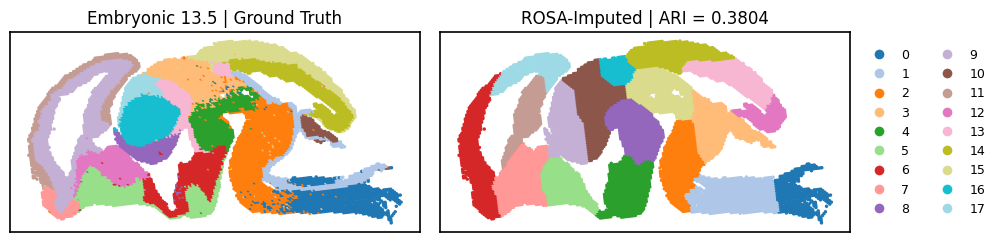

In [8]:
# Spatial domain segmentation on the Embryonic 13.5 slice
target_mask = (adata.obs['time_point'] == target_slice_name).values
spatial_coords = adata.obsm['spatial'][target_mask]

pca_gt = PCA(n_components=40, random_state=seed)
adata_target = sc.AnnData(X=X_true.copy())
adata_target.obsm['X_feat'] = pca_gt.fit_transform(adata_target.X)
optimize_leiden(
    adata_target,
    n_clusters=18,
    used_obsm='X_feat',
    add_obs='X_leiden',
    random_state=seed,
    verbose=False,
)
gt_labels = adata_target.obs['X_leiden'].astype('category')

pca_rosa = PCA(n_components=40, random_state=seed)
adata_rosa = sc.AnnData(X=X_pred.copy())
adata_rosa.obsm['ROSA_pred_feat'] = pca_rosa.fit_transform(adata_rosa.X)
optimize_leiden(
    adata_rosa,
    n_clusters=18,
    used_obsm='ROSA_pred_feat',
    add_obs='ROSA_pred_leiden',
    random_state=seed,
    verbose=False,
)
rosa_labels = adata_rosa.obs['ROSA_pred_leiden'].astype('category')

unique_clusters = sorted(
    gt_labels.cat.categories,
    key=lambda x: int(x) if str(x).isdigit() else str(x),
)
raw_tab20 = sns.color_palette('tab20', n_colors=20)
palette = [raw_tab20[i] for i in range(20) if i not in (14, 15)]
color_dict = dict(zip(unique_clusters, palette))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=False, dpi=100)

sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=gt_labels,
    palette=color_dict,
    s=6,
    edgecolor='none',
    ax=axes[0],
    legend=False,
    rasterized=True,
)
axes[0].set_title(
    f'{full_all_slice_names[all_slice_names.index(target_slice_name)]} | Ground Truth',
    fontsize=12
)

sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=rosa_labels,
    palette=color_dict,
    s=6,
    edgecolor='none',
    ax=axes[1],
    legend=False,
    rasterized=True,
)
ari_val = adjusted_rand_score(gt_labels, rosa_labels)
axes[1].set_title(f'ROSA-Imputed | ARI = {ari_val:.4f}', fontsize=12)

for ax in axes:
    ax.set_aspect(1, adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')

plt.subplots_adjust(left=0.03, right=0.87, top=0.92, bottom=0.08, wspace=0.05)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_dict[cluster],
        markersize=8,
        label=str(cluster),
    )
    for cluster in unique_clusters
]
fig.legend(
    handles=legend_handles,
    fontsize=9,
    loc='center left',
    bbox_to_anchor=(0.875, 0.5),
    frameon=False,
    ncol=2,
)

plt.show()

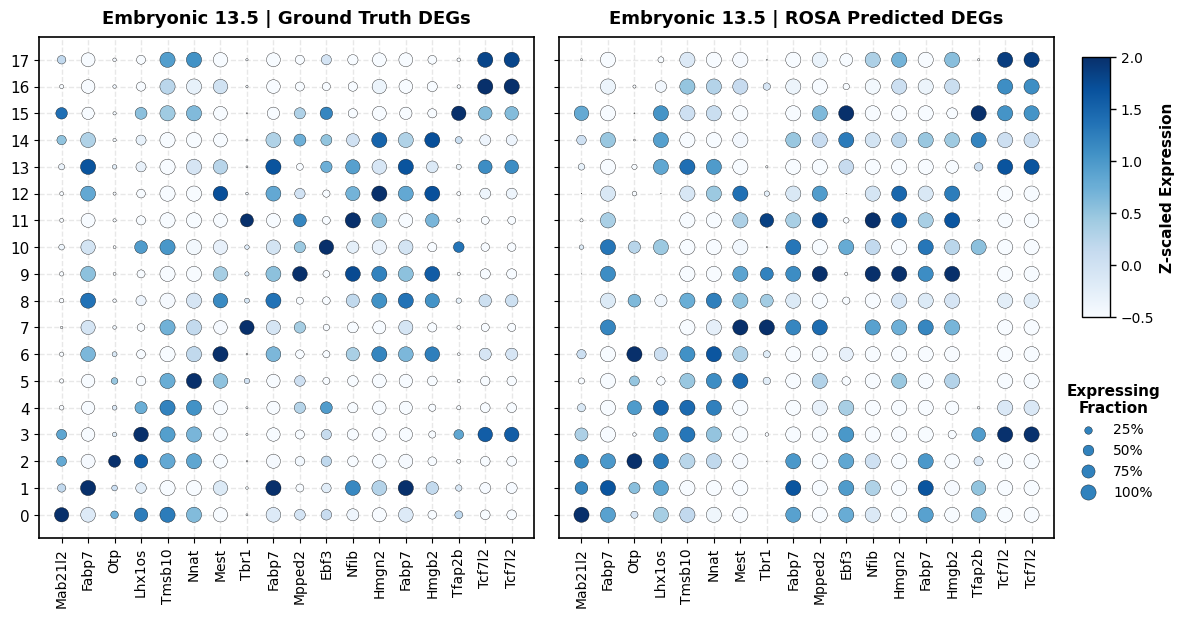

In [9]:
# Differentially expressed gene analysis on the Embryonic 13.5 slice
var_df = pd.DataFrame(index=adata.var_names)
adata_deg_gt = sc.AnnData(X=X_true.copy(), obs=pd.DataFrame({'X_leiden': gt_labels}), var=var_df)
adata_deg_rosa = sc.AnnData(X=X_pred.copy(), obs=pd.DataFrame({'X_leiden': gt_labels}), var=var_df)

sc.tl.rank_genes_groups(adata_deg_gt, groupby='X_leiden', method='wilcoxon', key_added='deg_gt')

selected_markers = []
for cl in unique_clusters:
    df_deg = sc.get.rank_genes_groups_df(adata_deg_gt, group=str(cl), key='deg_gt')
    top_gene = df_deg['names'].iloc[0]
    selected_markers.append(top_gene)

def get_dotplot_data(adata_obj, groupby, genes, cluster_order, expr_threshold=0.5):
    df_list = []
    X_mat = (
        adata_obj.X.toarray()
        if hasattr(adata_obj.X, 'toarray')
        else np.asarray(adata_obj.X)
    )
    gene_indices = [adata_obj.var_names.get_loc(g) for g in genes]

    for cl in cluster_order:
        cells_mask = (adata_obj.obs[groupby].astype(str) == str(cl)).values
        if not np.any(cells_mask):
            continue
        sub_X = X_mat[cells_mask][:, gene_indices]
        mean_exprs = np.mean(sub_X, axis=0)
        fractions = np.mean(sub_X > expr_threshold, axis=0)

        for idx, g in enumerate(genes):
            df_list.append({
                'Cluster': str(cl),
                'Gene_Idx': idx,
                'Gene': g,
                'MeanExpr': mean_exprs[idx],
                'Fraction': fractions[idx],
            })

    return pd.DataFrame(df_list)

df_gt = get_dotplot_data(adata_deg_gt, 'X_leiden', selected_markers, unique_clusters)
df_rosa = get_dotplot_data(adata_deg_rosa, 'X_leiden', selected_markers, unique_clusters)

df_gt['ExprScaled'] = df_gt.groupby('Gene_Idx')['MeanExpr'].transform(
    lambda x: zscore(x) if np.std(x) > 1e-8 else 0
)
df_rosa['ExprScaled'] = df_rosa.groupby('Gene_Idx')['MeanExpr'].transform(
    lambda x: zscore(x) if np.std(x) > 1e-8 else 0
)

fig_width = max(14, len(selected_markers) * 0.75)
fig, (ax_gt, ax_rosa) = plt.subplots(1, 2, figsize=(fig_width, 6.5), sharey=True, dpi=100)
cluster_to_y = {str(cl): i for i, cl in enumerate(unique_clusters)}

def plot_dots(ax, df, title):
    x_vals = df['Gene_Idx'].values
    y_vals = [cluster_to_y[str(c)] for c in df['Cluster']]
    sizes = df['Fraction'] * 120
    colors = df['ExprScaled']

    sc_plot = ax.scatter(
        x_vals,
        y_vals,
        s=sizes,
        c=colors,
        cmap='Blues',
        edgecolors='black',
        linewidths=0.25,
        alpha=1.0,
        vmin=-0.5,
        vmax=2.0,
        zorder=5,
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(range(len(selected_markers)))
    ax.set_xticklabels(selected_markers, rotation=90, fontsize=10)
    ax.set_yticks(range(len(unique_clusters)))
    ax.set_yticklabels([f'{c}' for c in unique_clusters], fontsize=11)
    ax.grid(True, linestyle='--', linewidth=1.0, color='#d3d3d3', alpha=0.5, zorder=0)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')

    return sc_plot

sc_gt = plot_dots(ax_gt, df_gt, 'Embryonic 13.5 | Ground Truth DEGs')
sc_rosa = plot_dots(ax_rosa, df_rosa, 'Embryonic 13.5 | ROSA Predicted DEGs')

plt.subplots_adjust(wspace=0.05, right=0.85)

cax = fig.add_axes([0.87, 0.45, 0.02, 0.4])
cbar = plt.colorbar(sc_gt, cax=cax)
cbar.set_label('Z-scaled Expression', fontsize=11, fontweight='bold')
cbar.outline.set_linewidth(1.0)
cbar.ax.tick_params(axis='y', length=4, width=1.0, labelsize=10)

leg_sizes = [0.25, 0.5, 0.75, 1.0]
leg_handles = [
    plt.scatter(
        [],
        [],
        s=sz * 120,
        color='#3182bd',
        alpha=1.0,
        edgecolors='black',
        linewidths=0.25,
    )
    for sz in leg_sizes
]
leg_labels = [f'{int(sz * 100)}%' for sz in leg_sizes]

leg = fig.legend(
    leg_handles,
    leg_labels,
    title='Expressing\nFraction',
    loc='lower left',
    bbox_to_anchor=(0.85, 0.15),
    frameon=False,
    fontsize=10,
    title_fontsize=11,
)
leg.get_title().set_ha('center')
leg.get_title().set_fontweight('bold')

plt.show()

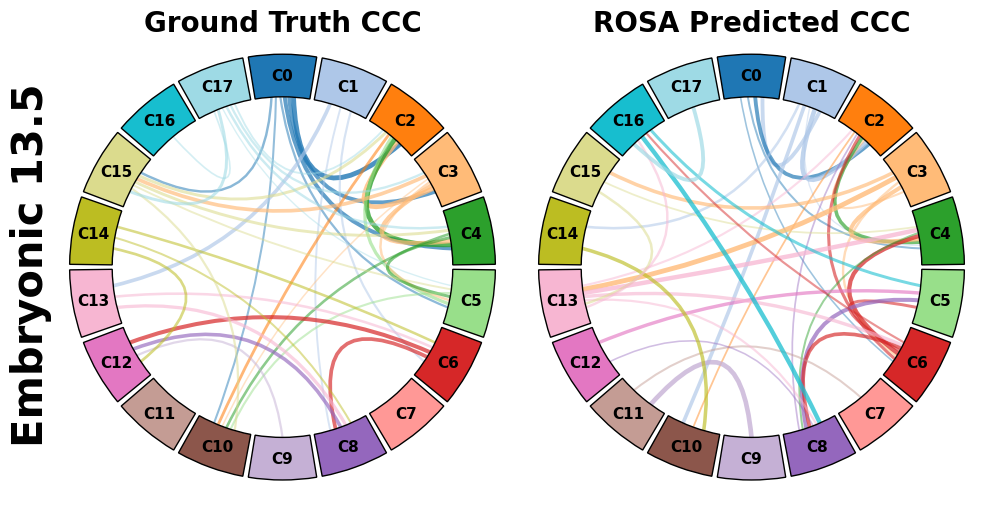

We captured 13 shared strong interaction pairs.
Top shared interaction pairs:
  Top 1: Cluster Pair: C0 <---> C2 | GT Score: 1.0000 | ROSA Score: 0.9911.
  Top 2: Cluster Pair: C2 <---> C4 | GT Score: 0.9965 | ROSA Score: 0.9887.
  Top 3: Cluster Pair: C2 <---> C3 | GT Score: 0.9954 | ROSA Score: 0.9761.
  Top 4: Cluster Pair: C3 <---> C4 | GT Score: 0.9852 | ROSA Score: 0.9931.
  Top 5: Cluster Pair: C0 <---> C4 | GT Score: 0.9828 | ROSA Score: 0.9750.


In [10]:
# Cell-cell communication analysis on the Embryonic 13.5 slice
import matplotlib.patches as patches
from matplotlib.path import Path

cluster_colors = {str(cl): color_dict[cl] for cl in unique_clusters}

n_c = len(unique_clusters)
cluster_gt_means = np.array([
    X_true[(gt_labels.astype(str) == str(cl)).values].mean(axis=0)
    for cl in unique_clusters
])
cluster_rosa_means = np.array([
    X_pred[(gt_labels.astype(str) == str(cl)).values].mean(axis=0)
    for cl in unique_clusters
])

net_gt = np.corrcoef(cluster_gt_means)
net_rosa = np.corrcoef(cluster_rosa_means)
np.fill_diagonal(net_gt, 0)
np.fill_diagonal(net_rosa, 0)

net_gt = np.clip(net_gt, 0, None)
net_rosa = np.clip(net_rosa, 0, None)
net_gt /= net_gt.max()
net_rosa /= net_rosa.max()

top_percentile_eval = 75
thresh_gt_eval = np.percentile(net_gt[net_gt > 0], top_percentile_eval)
thresh_rosa_eval = np.percentile(net_rosa[net_rosa > 0], top_percentile_eval)

common_records = []
for i in range(n_c):
    for j in range(i + 1, n_c):
        w_gt = net_gt[i, j]
        w_rosa = net_rosa[i, j]
        if w_gt >= thresh_gt_eval and w_rosa >= thresh_rosa_eval:
            c1, c2 = unique_clusters[i], unique_clusters[j]
            common_records.append({
                'Slice': target_slice_name,
                'Cluster_Pair': f'C{c1} <---> C{c2}',
                'GT_Score': w_gt,
                'ROSA_Score': w_rosa
            })

df_common_comm = pd.DataFrame(common_records)

fig, (ax_gt, ax_rosa) = plt.subplots(1, 2, figsize=(10.8, 6), dpi=100)
fig.text(
    0.02,
    0.5,
    'Embryonic 13.5',
    fontsize=30,
    fontweight='bold',
    va='center',
    ha='center',
    rotation=90,
)

def plot_circos_network(ax, net_matrix, title, top_percentile):
    ax.set_aspect('equal')
    ax.axis('off')

    r_inner = 1.0
    r_outer = 1.25
    r_text = 1.125

    sector_angle = 360.0 / n_c
    gap = 1.5
    arc_len = sector_angle - gap

    cluster_angle_bounds = {}
    for i in range(n_c):
        st = 90.0 - i * sector_angle - arc_len / 2.0
        et = st + arc_len
        cluster_angle_bounds[i] = (st, et)

    non_zero_weights = net_matrix[net_matrix > 0]
    thresh = (
        np.percentile(non_zero_weights, top_percentile)
        if len(non_zero_weights) > 0
        else 0.5
    )

    edges = []
    cluster_connected_neighbors = {i: [] for i in range(n_c)}

    for i in range(n_c):
        for j in range(i + 1, n_c):
            weight = net_matrix[i, j]
            if weight >= thresh:
                edges.append((i, j, weight))
                cluster_connected_neighbors[i].append(j)
                cluster_connected_neighbors[j].append(i)

    cluster_edge_angles = {i: {} for i in range(n_c)}
    for i in range(n_c):
        neighbors = sorted(cluster_connected_neighbors[i])
        k = len(neighbors)
        if k == 0:
            continue
        st, et = cluster_angle_bounds[i]
        if k == 1:
            cluster_edge_angles[i][neighbors[0]] = (st + et) / 2.0
        else:
            margin = (et - st) * 0.3
            sub_angles = np.linspace(st + margin, et - margin, k)
            for neighbor, ang in zip(neighbors, sub_angles):
                cluster_edge_angles[i][neighbor] = ang

    for i, j, weight in edges:
        ang_i = cluster_edge_angles[i][j]
        ang_j = cluster_edge_angles[j][i]

        rad_i = np.radians(ang_i)
        rad_j = np.radians(ang_j)

        x1, y1 = r_inner * np.cos(rad_i), r_inner * np.sin(rad_i)
        x2, y2 = r_inner * np.cos(rad_j), r_inner * np.sin(rad_j)

        ctrl_scale = 0.25
        cx, cy = (x1 + x2) * ctrl_scale / 2.0, (y1 + y2) * ctrl_scale / 2.0

        path_data = [
            (Path.MOVETO, (x1, y1)),
            (Path.CURVE3, (cx, cy)),
            (Path.CURVE3, (x2, y2)),
        ]
        path = Path([p[1] for p in path_data], [p[0] for p in path_data])

        source_idx = (i if cluster_gt_means[i].sum() >= cluster_gt_means[j].sum() else j)
        edge_color = cluster_colors[str(unique_clusters[source_idx])]

        norm_w = (weight - thresh) / (1.0 - thresh + 1e-5)
        lw = 1.0 + norm_w * 2.5
        alpha = 0.4 + norm_w * 0.4

        patch = patches.PathPatch(
            path,
            facecolor='none',
            edgecolor=edge_color,
            linewidth=lw,
            alpha=alpha,
            zorder=1,
        )
        ax.add_patch(patch)

    for i, cl in enumerate(unique_clusters):
        start_angle, end_angle = cluster_angle_bounds[i]
        color = cluster_colors[str(cl)]

        wedge = patches.Wedge(
            center=(0, 0),
            r=r_outer,
            width=(r_outer - r_inner),
            theta1=start_angle,
            theta2=end_angle,
            facecolor=color,
            edgecolor='black',
            linewidth=1.0,
            zorder=3,
        )
        ax.add_patch(wedge)

        mid_rad = np.radians((start_angle + end_angle) / 2.0)
        tx = r_text * np.cos(mid_rad)
        ty = r_text * np.sin(mid_rad)

        ax.text(
            tx,
            ty,
            f'C{cl}',
            fontsize=11,
            fontweight='bold',
            ha='center',
            va='center',
            zorder=4,
        )

    ax.set_title(title, fontsize=20, fontweight='bold', pad=0)
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)

plot_circos_network(ax_gt, net_gt, 'Ground Truth CCC', top_percentile_eval)
plot_circos_network(ax_rosa, net_rosa, 'ROSA Predicted CCC', top_percentile_eval)

plt.subplots_adjust(left=0.04, wspace=0.02)
plt.show()

# Print summary statistics and top shared cell-cell interaction pairs
count = len(df_common_comm)
print(f'We captured {count} shared strong interaction pairs.')

df_top = df_common_comm.sort_values(by='GT_Score', ascending=False).head(5)
print('Top shared interaction pairs:')
for rank, (_, row) in enumerate(df_top.iterrows(), 1):
    print(f"  Top {rank}: Cluster Pair: {row['Cluster_Pair']} | "
          f"GT Score: {row['GT_Score']:.4f} | ROSA Score: {row['ROSA_Score']:.4f}.")